In [134]:
import yfinance as yf
import pandas as pd
import warnings
import numpy as np
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")


In [135]:
ibm_wmt = yf.download(tickers = 'ibm wmt', period = '5y', interval = '1d', rounding= True)
ibm_wmt = ibm_wmt['Close']
ibm_wmt

[*********************100%***********************]  2 of 2 completed


Ticker,IBM,WMT
Date,,
2021-03-01,94.56,40.91
2021-03-02,94.24,40.52
2021-03-03,95.83,39.74
2021-03-04,94.07,39.72
2021-03-05,96.20,40.21
...,...,...
2026-02-23,223.35,125.81
2026-02-24,229.32,126.75
2026-02-25,237.54,125.75


<function matplotlib.pyplot.show(close=None, block=None)>

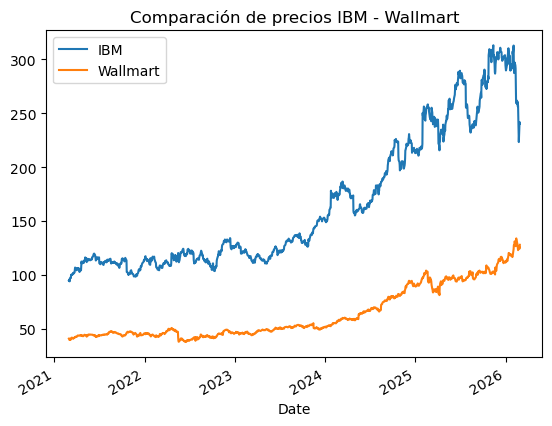

In [136]:
ibm_wmt['IBM'].plot()
ibm_wmt['WMT'].plot()
plt.legend(['IBM', 'Wallmart'])
plt.title('Comparación de precios IBM - Wallmart')
plt.show

In [137]:
#rendimiento de ambos

rend_ibm_wmt = ibm_wmt.pct_change()
rend_ibm_wmt = rend_ibm_wmt.dropna()
rend_ibm_wmt

Ticker,IBM,WMT
Date,,
2021-03-02,-0.003384,-0.009533
2021-03-03,0.016872,-0.019250
2021-03-04,-0.018366,-0.000503
2021-03-05,0.022643,0.012336
2021-03-08,0.016112,-0.009450
...,...,...
2026-02-23,-0.131475,0.022929
2026-02-24,0.026729,0.007472
2026-02-25,0.035845,-0.007890


In [138]:
# ¿Esta correlaciono un incremento en el rendimiento entre las 2 empresas?

correlacion = rend_ibm_wmt ['IBM'].corr(rend_ibm_wmt ['WMT'])
print('Correlacion entre IBM y Wallmart:', correlacion)

correlacion


Correlacion entre IBM y Wallmart: 0.18841369835946029


np.float64(0.18841369835946029)

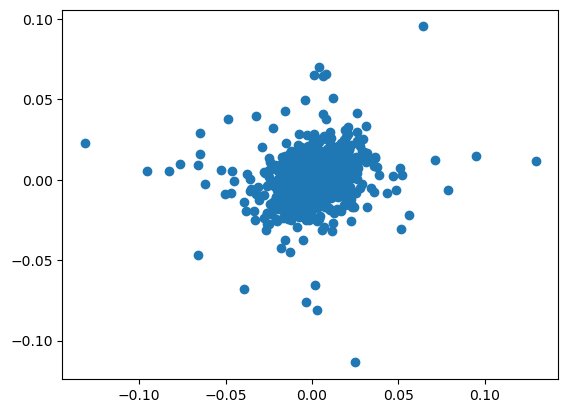

In [139]:
plt.scatter(rend_ibm_wmt['IBM'],rend_ibm_wmt['WMT'])
plt.show()

In [140]:
import statsmodels.api as sm
rend_ibm_wmt = sm.add_constant(rend_ibm_wmt) # se agrega la constante de 1´s
rend_ibm_wmt

,const,IBM,WMT
Date,,,
2021-03-02,1.0,-0.003384,-0.009533
2021-03-03,1.0,0.016872,-0.019250
2021-03-04,1.0,-0.018366,-0.000503
2021-03-05,1.0,0.022643,0.012336
2021-03-08,1.0,0.016112,-0.009450
...,...,...,...
2026-02-23,1.0,-0.131475,0.022929
2026-02-24,1.0,0.026729,0.007472
2026-02-25,1.0,0.035845,-0.007890


In [141]:
X = rend_ibm_wmt[['const','WMT']]
Y = rend_ibm_wmt['IBM']

print("NaN en X:\n", X.isna().sum())
print("NaN en Y:\n", Y.isna().sum())

print("Inf en X:\n", np.isinf(X).sum())
print("Inf en Y:\n", np.isinf(Y).sum())

NaN en X:
 const    0
WMT      0
dtype: int64
NaN en Y:
 0
Inf en X:
 const    0
WMT      0
dtype: int64
Inf en Y:
 0


In [142]:
regresion = sm.OLS(rend_ibm_wmt['IBM'], rend_ibm_wmt[['const', 'WMT']]).fit()
print(regresion.summary())

                            OLS Regression Results                            
Dep. Variable:                    IBM   R-squared:                       0.035
Model:                            OLS   Adj. R-squared:                  0.035
Method:                 Least Squares   F-statistic:                     46.12
Date:                Sun, 01 Mar 2026   Prob (F-statistic):           1.71e-11
Time:                        19:32:21   Log-Likelihood:                 3460.9
No. Observations:                1255   AIC:                            -6918.
Df Residuals:                    1253   BIC:                            -6908.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0006      0.000      1.481      0.1

In [143]:
# Calculo del indice de autocorrelacion...que tan fuerte es la correlacion de cada observacion contra su predecesor

autocorrelacion = rend_ibm_wmt['IBM'].autocorr()
autocorrelacion


np.float64(0.0033291419770788457)

In [189]:
corr_precios = ibm_wmt['IBM'].corr(ibm_wmt['WMT'])
print(corr_precios)
#El coeficiente de correlación entre los precios de IBM y Walmart es 0.966, lo que indica una relación lineal positiva muy fuerte entre ambas series.
#Esto sugiere que los precios de ambas acciones tienden a moverse conjuntamente a lo largo del tiempo. Sin embargo, esta alta correlación puede
#estar influenciada por la tendencia creciente común en ambas series, característica de precios financieros no estacionarios.

0.9661183879054592


In [144]:
#Existe una relación positiva débil entre los rendimientos diarios de IBM y Walmart. El coeficiente beta estimado es 0.2222, 
#lo que indica que un aumento de 1% en el rendimiento de Walmart se asocia con un incremento aproximado de 0.22% en el rendimiento de IBM. 
#Aunque el poder explicativo del modelo es bajo (R² = 3.5%), la relación es estadísticamente significativa al 1%.

In [145]:
ibm = ibm_wmt['IBM']
print(len(ibm))

1256


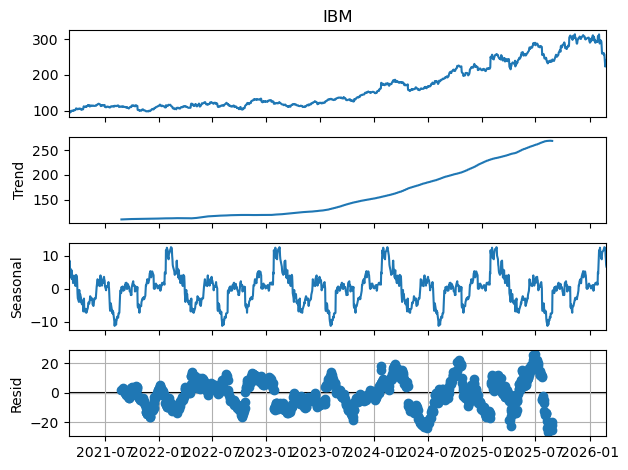

In [146]:
# Descomppsición IBM
decomposed_ibm =  sm.tsa.seasonal_decompose(ibm, period=252)
figure = decomposed_ibm.plot()
plt.grid()
plt.show()


[1.         0.99765811 0.99536098 0.99302729 0.9909952  0.9890579
 0.98666312 0.98415    0.98155291 0.97884808 0.97614552 0.97355219
 0.97063044 0.9673347  0.96376784 0.96029448 0.95708344 0.95395981
 0.95079639 0.94732554 0.94402925 0.9406698  0.9374737  0.93434741
 0.93097797 0.92780491 0.92447435 0.92125719 0.91813155 0.91479472
 0.91156173]


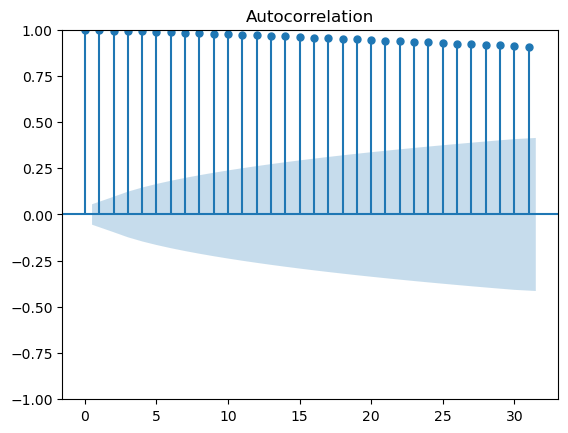

In [147]:
# Correlograma IBM

# generación de la funcion de autocorrelacion

from statsmodels.tsa.stattools import acf
from statsmodels.graphics.tsaplots import plot_acf

acf_array = acf(ibm)
print(acf_array)

plot_acf(ibm, alpha=0.05)
plt.show()

In [148]:
#El correlograma de los precios de IBM muestra autocorrelaciones extremadamente altas y persistentes en múltiples rezagos. 
#Esto indica fuerte dependencia temporal y confirma que la serie no es estacionaria, característica típica de precios financieros 
#que siguen un comportamiento cercano a un random walk.

In [149]:
wmt = ibm_wmt['WMT']
print(len(wmt))

1256


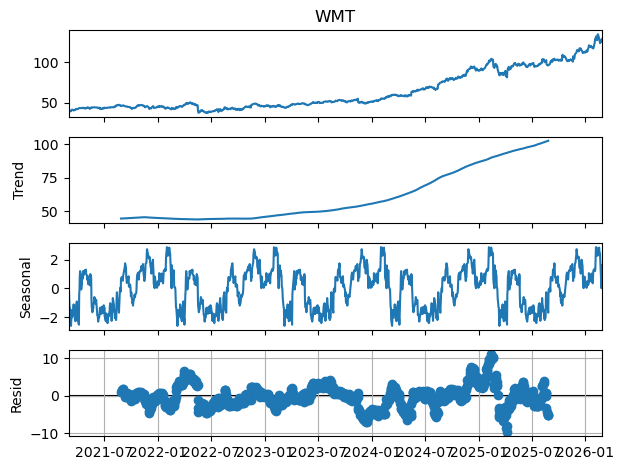

In [150]:
# Descomposición WMT
decomposed_wmt =  sm.tsa.seasonal_decompose(wmt, period=252)
figure = decomposed_wmt.plot()
plt.grid()
plt.show()


[1.         0.99600797 0.99221208 0.98831179 0.98431501 0.98045917
 0.97693373 0.97320296 0.96926025 0.96507192 0.96054492 0.95590153
 0.95184015 0.94796449 0.94387364 0.93952854 0.93554259 0.93146786
 0.9274867  0.92382909 0.92057912 0.91750473 0.9145377  0.91159181
 0.90855449 0.90557868 0.90269141 0.89964217 0.89669691 0.89371667
 0.89080258]


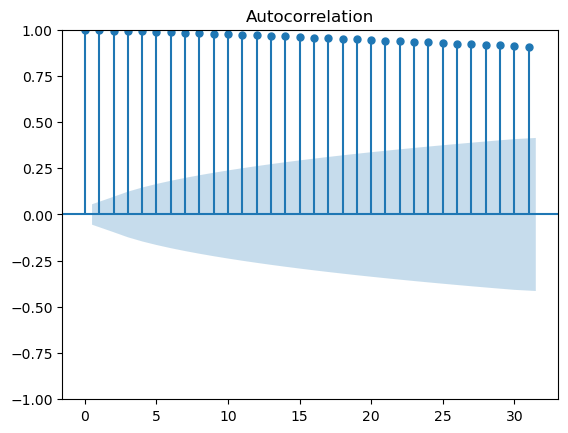

In [151]:
# Correlograma WMT

# generación de la funcion de autocorrelacion

from statsmodels.tsa.stattools import acf
from statsmodels.graphics.tsaplots import plot_acf

acf_array = acf(wmt)
print(acf_array)

plot_acf(ibm, alpha=0.05)
plt.show()

In [152]:
#Tanto IBM como Walmart presentan una fuerte tendencia creciente en el periodo analizado. La descomposición muestra que la tendencia 
#es el componente dominante en ambas series, mientras que la estacionalidad es relativamente débil.
#Los correlogramas evidencian autocorrelaciones muy altas y persistentes, confirmando que ambas series son no estacionarias y presentan 
#fuerte dependencia temporal, característica típica de precios financieros.

In [153]:
# Prueba de Dickey-Fuller para los prpecios de IBM

from statsmodels.tsa.stattools import adfuller

resultado = adfuller(ibm)
print("El valor P de la prueba es:", resultado[1])

El valor P de la prueba es: 0.76762702454294


In [154]:
#a prueba de Dickey-Fuller aumentada arroja un valor p de 0.9982, lo que implica que no se rechaza la hipótesis nula de presencia de raíz unitaria. 
#Por tanto, la serie de precios de IBM no es estacionaria, resultado consistente con la fuerte autocorrelación observada en el correlograma y 
#la tendencia creciente identificada en la descomposición.

In [155]:
# Prueba de Dickey-Fuller para los prpecios de IBM


resultado = adfuller(wmt)
print("El valor P de la prueba es:", resultado[1])

El valor P de la prueba es: 0.9982618588075273


In [156]:
#Tanto IBM como Walmart presentan resultados similares en la prueba ADF para los precios, evidenciando no estacionariedad y presencia de raíz 
#unitaria, comportamiento típico de activos financieros.


In [157]:
# MEDIA MOVIL IBM

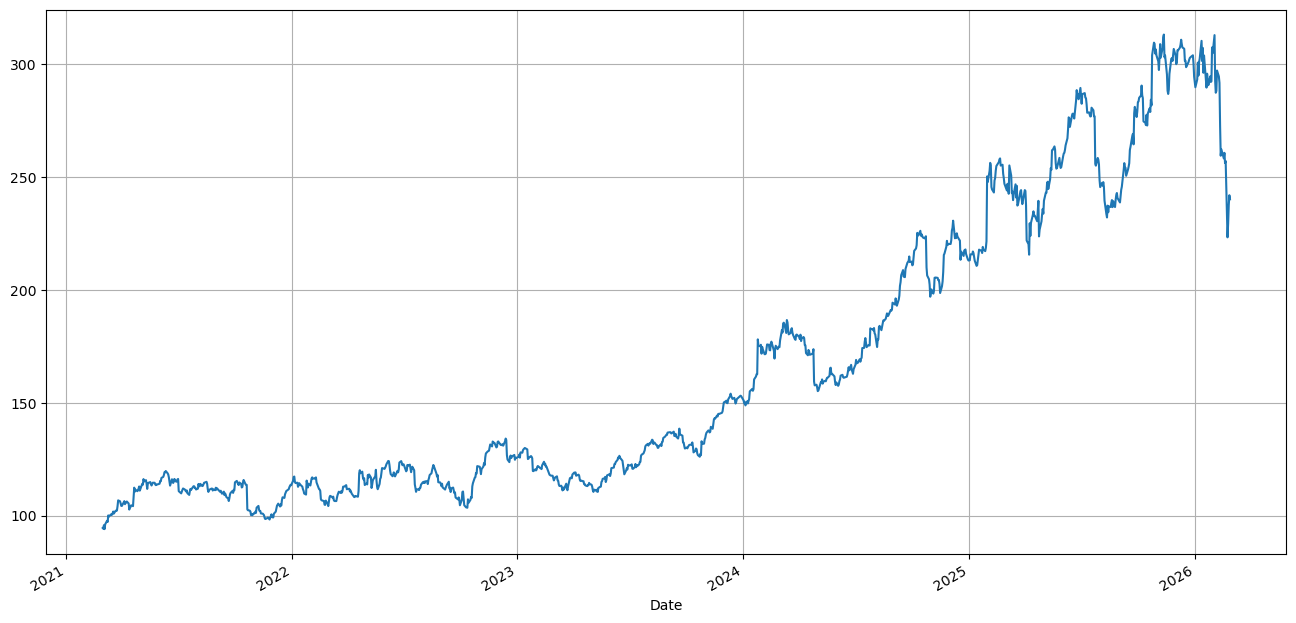

In [158]:


ibm.plot(figsize=(16,8)).grid()




In [159]:
# Predicción simple mediante promedios moviles
ibm.shape

(1256,)

In [160]:
len_train = int(1256 * .8)
len_train


1004

In [161]:
# Definición de grupo de entrenamiento y prueba

train = ibm[0:len_train]
test = ibm[len_train:]


In [162]:
len(train)

1004

In [163]:
len(test)

252

In [164]:
#Copia de la base de datos para calcular la media movil

y_pred = ibm.copy()
y_pred = pd.DataFrame(y_pred)

In [165]:
#Generar columna de pronostico

y_pred['pronostico'] = ibm.rolling(30).mean()
y_pred[0:35]

,IBM,pronostico
Date,,
2021-03-01,94.56,NaN
2021-03-02,94.24,NaN
2021-03-03,95.83,NaN
2021-03-04,94.07,NaN
2021-03-05,96.20,NaN
2021-03-08,97.75,NaN
2021-03-09,97.26,NaN
2021-03-10,100.15,NaN
2021-03-11,99.58,NaN


In [166]:
y_pred_m = y_pred.copy()
y_pred_m['pronostico'][29]= 'NaN'
for contador in range(30, 753):
    y_pred_m['pronostico'][contador] = y_pred['pronostico'][contador-1]
y_pred_m[0:35]

,IBM,pronostico
Date,,
2021-03-01,94.56,NaN
2021-03-02,94.24,NaN
2021-03-03,95.83,NaN
2021-03-04,94.07,NaN
2021-03-05,96.20,NaN
2021-03-08,97.75,NaN
2021-03-09,97.26,NaN
2021-03-10,100.15,NaN
2021-03-11,99.58,NaN


In [167]:
y_pred_m = pd.DataFrame(y_pred_m['pronostico'][1004:])
y_pred_m

,pronostico
Date,
2025-02-27,240.301333
2025-02-28,241.403
2025-03-03,242.346333
2025-03-04,243.319
2025-03-05,244.248333
...,...
2026-02-23,286.615
2026-02-24,284.175667
2026-02-25,281.746667


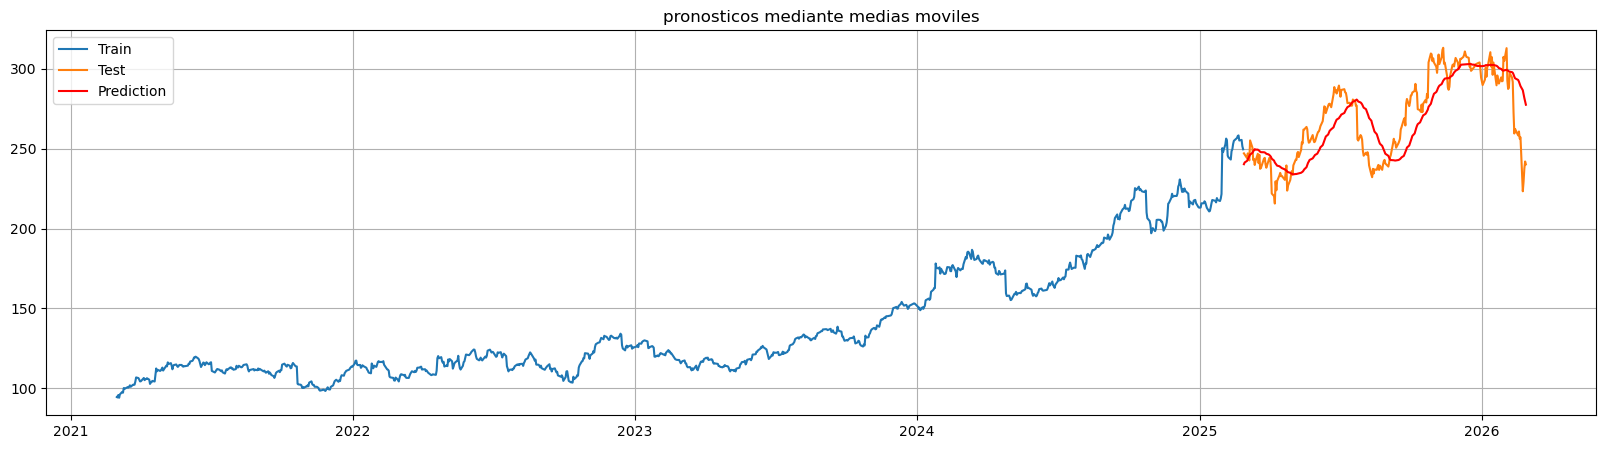

In [168]:
plt.figure(figsize=(20,5))
plt.grid()
plt.plot(train, label='Train')
plt.plot(test, label='Test')
plt.plot(y_pred_m['pronostico'], label='Prediction', color='red')
plt.legend(loc='best')
plt.title('pronosticos mediante medias moviles')
plt.show()

In [169]:
test = pd.DataFrame(test)
test

,IBM
Date,
2025-02-27,247.09
2025-02-28,246.32
2025-03-03,244.12
2025-03-04,247.07
2025-03-05,245.25
...,...
2026-02-23,223.35
2026-02-24,229.32
2026-02-25,237.54


In [170]:
frames = [test, y_pred_m]
result = pd.concat(frames, axis=1, join='inner')
result.columns = ['Observado', 'Pronosticado']
result


,Observado,Pronosticado
Date,,
2025-02-27,247.09,240.301333
2025-02-28,246.32,241.403
2025-03-03,244.12,242.346333
2025-03-04,247.07,243.319
2025-03-05,245.25,244.248333
...,...,...
2026-02-23,223.35,286.615
2026-02-24,229.32,284.175667
2026-02-25,237.54,281.746667


In [173]:
from sklearn.metrics import mean_squared_error


rmse = np.sqrt(mean_squared_error(test['IBM'], y_pred_m['pronostico'])).round(2)

mape = np.round(
    np.mean(np.abs((test['IBM'] - y_pred_m['pronostico']) / test['IBM'])) * 100,
    2
)

print("RMSE = ", rmse, "MAPE =", mape)

RMSE =  16.54 MAPE = 4.91


In [174]:
# Pronostico parael siguiente IBM
y_pred.tail(1)['pronostico']

Date
2026-02-27    277.53
Name: pronostico, dtype: float64

In [ ]:
# MEDIA MOVIL WMT

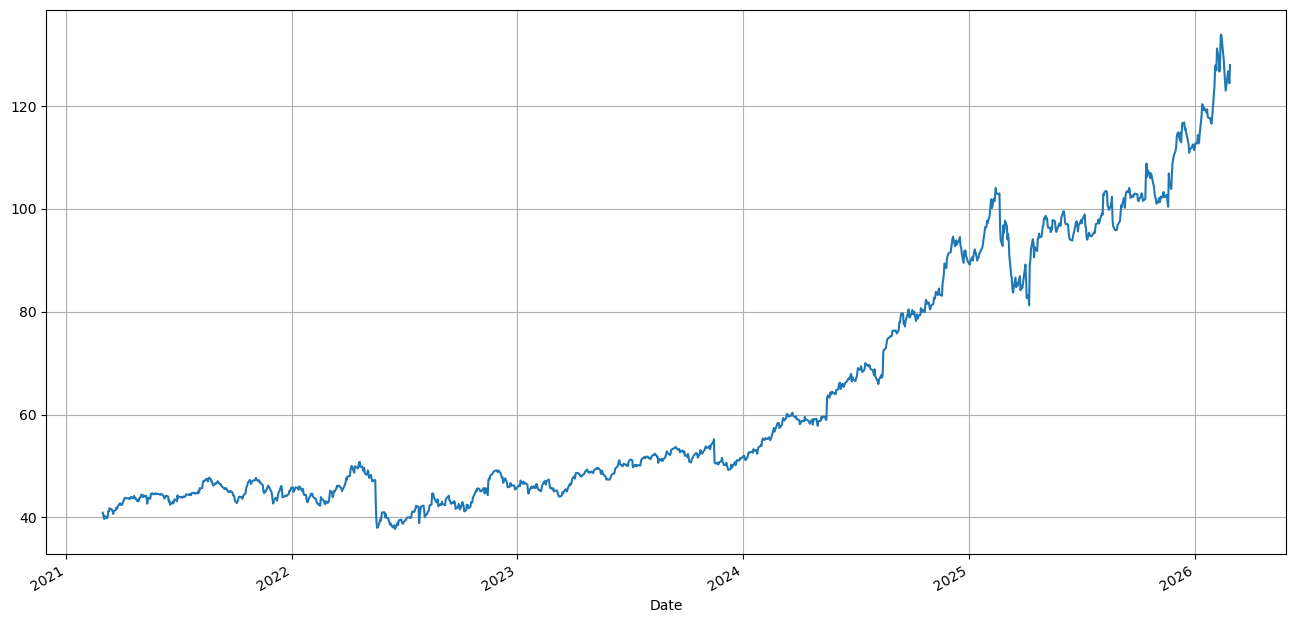

In [176]:
wmt.plot(figsize=(16,8)).grid()


In [179]:
train = wmt[0:len_train]
test = wmt[len_train:]


In [180]:
#Copia de la base de datos para calcular la media movil

y_pred = wmt.copy()
y_pred = pd.DataFrame(y_pred)

In [181]:
#Generar columna de pronostico

y_pred['pronostico'] = wmt.rolling(30).mean()
y_pred[0:35]

,WMT,pronostico
Date,,
2021-03-01,40.91,NaN
2021-03-02,40.52,NaN
2021-03-03,39.74,NaN
2021-03-04,39.72,NaN
2021-03-05,40.21,NaN
2021-03-08,39.83,NaN
2021-03-09,40.14,NaN
2021-03-10,41.17,NaN
2021-03-11,41.15,NaN


In [182]:
y_pred_m = y_pred.copy()
y_pred_m['pronostico'][29]= 'NaN'
for contador in range(30, 753):
    y_pred_m['pronostico'][contador] = y_pred['pronostico'][contador-1]
y_pred_m[0:35]

,WMT,pronostico
Date,,
2021-03-01,40.91,NaN
2021-03-02,40.52,NaN
2021-03-03,39.74,NaN
2021-03-04,39.72,NaN
2021-03-05,40.21,NaN
2021-03-08,39.83,NaN
2021-03-09,40.14,NaN
2021-03-10,41.17,NaN
2021-03-11,41.15,NaN


In [183]:
y_pred_m = pd.DataFrame(y_pred_m['pronostico'][1004:])
y_pred_m

,pronostico
Date,
2025-02-27,97.316
2025-02-28,97.556333
2025-03-03,97.764
2025-03-04,97.864
2025-03-05,97.959667
...,...
2026-02-23,123.072667
2026-02-24,123.48
2026-02-25,123.739333


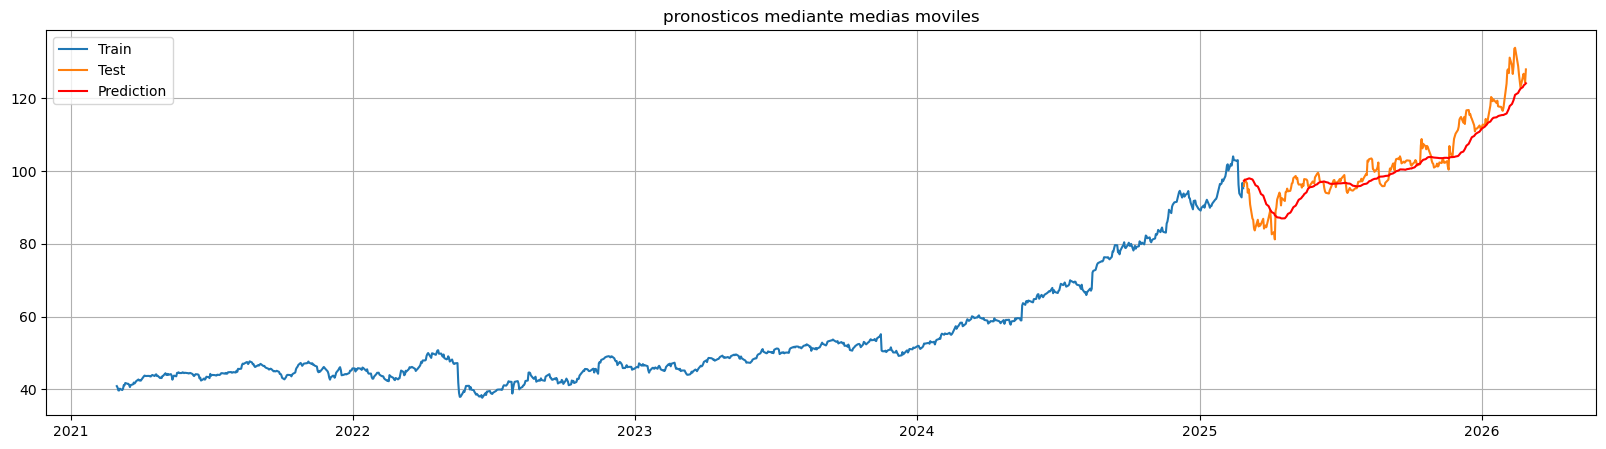

In [184]:
plt.figure(figsize=(20,5))
plt.grid()
plt.plot(train, label='Train')
plt.plot(test, label='Test')
plt.plot(y_pred_m['pronostico'], label='Prediction', color='red')
plt.legend(loc='best')
plt.title('pronosticos mediante medias moviles')
plt.show()

In [185]:
test = pd.DataFrame(test)
test

,WMT
Date,
2025-02-27,95.87
2025-02-28,97.68
2025-03-03,96.66
2025-03-04,94.07
2025-03-05,95.07
...,...
2026-02-23,125.81
2026-02-24,126.75
2026-02-25,125.75


In [186]:
frames = [test, y_pred_m]
result = pd.concat(frames, axis=1, join='inner')
result.columns = ['Observado', 'Pronosticado']
result


,Observado,Pronosticado
Date,,
2025-02-27,95.87,97.316
2025-02-28,97.68,97.556333
2025-03-03,96.66,97.764
2025-03-04,94.07,97.864
2025-03-05,95.07,97.959667
...,...,...
2026-02-23,125.81,123.072667
2026-02-24,126.75,123.48
2026-02-25,125.75,123.739333


In [187]:
from sklearn.metrics import mean_squared_error


rmse = np.sqrt(mean_squared_error(test['WMT'], y_pred_m['pronostico'])).round(2)

mape = np.round(
    np.mean(np.abs((test['WMT'] - y_pred_m['pronostico']) / test['WMT'])) * 100,
    2
)

print("RMSE = ", rmse, "MAPE =", mape)

RMSE =  4.82 MAPE = 3.58


In [188]:
# Pronostico parael siguiente WMT
y_pred.tail(1)['pronostico']

Date
2026-02-27    124.138333
Name: pronostico, dtype: float64

In [ ]:
#Aunque el modelo de medias móviles logra capturar la tendencia general de ambas series y presenta errores porcentuales relativamente bajos, 
#no se esperaría que estos pronósticos sean consistentemente precisos en un contexto financiero. Los precios de las acciones presentan comportamiento
#no estacionario y cercano a una caminata aleatoria, lo que limita la capacidad predictiva de modelos simples basados en promedios históricos.